# 03. 호기별 Feature Sensitivity와 클러스터 구조

**목적**: 11 호기가 서로 다른 feature 반응을 가지는지 정량 확인. 이 결과가:
- 1층 베이지안의 **지역 random slope** 정당화
- 2층 GRU의 **FiLM conditioning** 정당화

**증명하고 싶은 것**:
1. 호기별로 feature 반응 계수가 다르다 → 글로벌 단일 계수로 부족
2. 고흥만(수상 PV)이 내륙과 구조적으로 다르다 → 특이 처리 필요
3. 자연 군집이 존재한다 → 지역 그룹 사용 가능

**데이터**:
- PV: 2024년 **11 호기** 시간별 (`data_strategy.md §2`)
- ASOS: 2024년 11 관측소
- 호기 메타데이터: **하드코딩** (`data_strategy.md §5` 매핑 + 용량 공식 CSV 기반)
- ⚠️ 삼천포 #1 제외됨 (2025년 중반부터 가동 축소)

## 0. 데이터 로드 및 호기 메타데이터

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os, warnings
from numpy.linalg import pinv
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# ============================================================
# 데이터 전략 (2026-04-22 기준):
#   - PV: 2022-01 ~ 2025-12 호기별 시간별 (solar_hourly_long.csv)
#   - GHI: GK-2A 위성 2km 격자, 사이트별 직접 측정 (W/m²)
#         완성월 46개 사용 (2022-06, 2023-03은 1일 결측이라 제외)
#   - 기온/습도/풍속: ASOS 11 관측소 (icsr은 GK-2A로 대체하므로 제외)
# ============================================================

INCOMPLETE_MONTHS = {'202206', '202303'}  # 각 1일 결측

# ----- PV 로드 -----
pv = pd.read_csv('../../data/processed/solar_hourly_long.csv', parse_dates=['date','datetime'])
pv['unit'] = pv['unit'].astype(str)
pv['site_unit'] = pv['site'] + '#' + pv['unit']

# ----- ASOS (ta, hm, ws만) -----
asos_files = sorted(glob.glob('../../data/asos_hourly/asos_hourly_*.csv'))
asos = pd.concat([pd.read_csv(f) for f in asos_files], ignore_index=True)
asos['tm'] = pd.to_datetime(asos['tm'])
asos = asos[['tm','stnNm','ta','hm','ws']]

# ----- GK-2A GHI (완성월만) -----
ghi_files = sorted(glob.glob('../../data/gk2a_ghi/gk2a_ghi_*.csv'))
ghi_files = [f for f in ghi_files
             if os.path.basename(f).replace('gk2a_ghi_','').replace('.csv','') not in INCOMPLETE_MONTHS]
ghi_wide = pd.concat([pd.read_csv(f) for f in ghi_files], ignore_index=True)
ghi_wide['datetime_kst'] = pd.to_datetime(ghi_wide['datetime_kst'])
gk2a_site_cols = [c for c in ghi_wide.columns if c != 'datetime_kst']
ghi_long = ghi_wide.melt(id_vars=['datetime_kst'], value_vars=gk2a_site_cols,
                          var_name='gk2a_site', value_name='ghi')

# ----- 호기 메타데이터 (11 호기, 용량 공식 CSV + GK-2A 컬럼 매핑) -----
UNIT_META = {
    '경상대태양광#1':       dict(capacity_kw=905,   stnNm='진주',   gk2a='경상대',    lat=35.15, lon=128.10, is_floating=False, region='내륙남부'),
    '고흥만 수상태양광#1':    dict(capacity_kw=63481, stnNm='고흥',   gk2a='고흥만수상', lat=34.60, lon=127.30, is_floating=True,  region='수상'),
    '광양항세방태양광#1':    dict(capacity_kw=2993,  stnNm='광양시', gk2a='광양항세방', lat=34.95, lon=127.72, is_floating=False, region='해안남부'),
    '구미태양광#1':         dict(capacity_kw=992,   stnNm='구미',   gk2a='구미',      lat=36.11, lon=128.42, is_floating=False, region='내륙중부'),
    '두산엔진MG태양광#1':    dict(capacity_kw=77,    stnNm='창원',   gk2a='창원',      lat=35.23, lon=128.68, is_floating=False, region='내륙남부'),
    '삼천포태양광#2':       dict(capacity_kw=990,   stnNm='남해',   gk2a='삼천포',    lat=34.94, lon=128.23, is_floating=False, region='해안남부'),
    '삼천포태양광#3':       dict(capacity_kw=350,   stnNm='남해',   gk2a='삼천포',    lat=34.94, lon=128.23, is_floating=False, region='해안남부'),
    '영흥태양광#1':         dict(capacity_kw=1000,  stnNm='인천',   gk2a='영흥',      lat=37.26, lon=126.46, is_floating=False, region='해안서부'),
    '영흥태양광#2':         dict(capacity_kw=993,   stnNm='인천',   gk2a='영흥',      lat=37.26, lon=126.46, is_floating=False, region='해안서부'),
    '영흥태양광#5#1':       dict(capacity_kw=3500,  stnNm='인천',   gk2a='영흥',      lat=37.26, lon=126.46, is_floating=False, region='해안서부'),
    '예천태양광#1':         dict(capacity_kw=2000,  stnNm='안동',   gk2a='예천',      lat=36.65, lon=128.46, is_floating=False, region='내륙북부'),
}
meta_df = pd.DataFrame(UNIT_META).T
meta_df.index.name = 'site_unit'

# 11 호기 필터 + 사이트 매핑 컬럼
pv = pv[pv['site_unit'].isin(UNIT_META.keys())].copy()
pv['stnNm']     = pv['site_unit'].map(lambda u: UNIT_META[u]['stnNm'])
pv['gk2a_site'] = pv['site_unit'].map(lambda u: UNIT_META[u]['gk2a'])

# 완성월만 필터
pv['ym'] = pv['datetime'].dt.strftime('%Y%m')
pv = pv[~pv['ym'].isin(INCOMPLETE_MONTHS)].copy()

# PV + ASOS (ta, hm, ws)
merged = pv.merge(asos, left_on=['datetime','stnNm'], right_on=['tm','stnNm'], how='left')

# PV + GK-2A GHI
merged = merged.merge(ghi_long, left_on=['datetime','gk2a_site'],
                      right_on=['datetime_kst','gk2a_site'], how='left')

# 낮 시간 (6~20시)
day = merged[(merged['hour'] >= 6) & (merged['hour'] <= 20)].copy()
day['month']  = day['date'].dt.month
day['season'] = day['month'].map(lambda m: '겨울' if m in [12,1,2] else '봄' if m in [3,4,5] else '여름' if m in [6,7,8] else '가을')

print(f'데이터: {len(day):,} 행, 호기 {day["site_unit"].nunique()}개')
print(f'기간: {day["date"].min()} ~ {day["date"].max()}')
print(f'사용 월: {day["ym"].nunique()}개 (2022-06, 2023-03 제외)')
print(f'ASOS 매칭: {day["ta"].notna().sum():,} / {len(day):,}')
print(f'GK-2A GHI 매칭: {day["ghi"].notna().sum():,} / {len(day):,}')
print(f'  → NaN 제거 후 각 변수 가용 샘플: '
      f'ghi={day["ghi"].notna().sum():,}, ta={day["ta"].notna().sum():,}, '
      f'hm={day["hm"].notna().sum():,}, ws={day["ws"].notna().sum():,}')

## 1. 호기 메타데이터 요약

하드코딩. 이후 분석에서 conditioning feature로 활용 가능한 후보:
- `capacity_kw` (용량) — 평가 정규화용
- `lat` (위도) — 연속 conditioning
- `is_floating` (수상/내륙) — 이진 conditioning
- `region` (지역 클러스터 예비 분류) — 범주 conditioning

In [8]:
meta_display = meta_df[['capacity_kw','stnNm','lat','lon','is_floating','region']].copy()
meta_display = meta_display.sort_values('capacity_kw', ascending=False)
print(meta_display.to_string())
print(f'\n수상 PV: {meta_display["is_floating"].sum()}개 (고흥만)')
print(f'내륙 PV: {(~meta_display["is_floating"]).sum()}개')
print(f'\n지역 클러스터 분포:')
print(meta_display['region'].value_counts().to_string())
print(f'\n위도 범위: {meta_display["lat"].min():.2f}N ~ {meta_display["lat"].max():.2f}N')
print(f'용량 범위: {meta_display["capacity_kw"].min()} ~ {meta_display["capacity_kw"].max()} kW')

            capacity_kw stnNm    lat     lon is_floating region
site_unit                                                      
고흥만 수상태양광#1       63481    고흥   34.6   127.3        True     수상
영흥태양광#5#1          3500    인천  37.26  126.46       False   해안서부
광양항세방태양광#1         2993   광양시  34.95  127.72       False   해안남부
예천태양광#1            2000    안동  36.65  128.46       False   내륙북부
영흥태양광#1            1000    인천  37.26  126.46       False   해안서부
영흥태양광#2             993    인천  37.26  126.46       False   해안서부
구미태양광#1             992    구미  36.11  128.42       False   내륙중부
삼천포태양광#2            990    남해  34.94  128.23       False   해안남부
경상대태양광#1            905    진주  35.15   128.1       False   내륙남부
삼천포태양광#3            350    남해  34.94  128.23       False   해안남부
두산엔진MG태양광#1          77    창원  35.23  128.68       False   내륙남부

수상 PV: 1개 (고흥만)
내륙 PV: -12개

지역 클러스터 분포:
region
해안서부    3
해안남부    3
내륙남부    2
수상      1
내륙북부    1
내륙중부    1

위도 범위: 34.60N ~ 37.26N
용량 범위: 77 ~ 63481 kW


## 2. 호기별 Feature Sensitivity 매트릭스 ⭐ 핵심

각 호기에 대해 **within-unit 표준화 OLS**로 계수 추출:
- 종속변수: 호기별 z-score된 gen_kwh
- 독립변수: 표준화된 `{icsr, ta, hm, ws}`
- 결과: **12 × 4 계수 매트릭스**

**볼 것**:
- Feature별 계수가 호기 간에 얼마나 다른가 (SD 크면 FiLM 필요)
- 고흥만이 다른 호기와 얼마나 떨어져 있는가

In [ ]:
features = ['ghi','ta','hm','ws']
units = sorted(day['site_unit'].unique())
beta_matrix = pd.DataFrame(index=units, columns=features, dtype=float)
se_matrix   = pd.DataFrame(index=units, columns=features, dtype=float)
r2_vec      = pd.Series(index=units, dtype=float, name='R²')

for u in units:
    g = day[day['site_unit']==u][['gen_kwh'] + features].dropna()
    if len(g) < 100:
        continue
    y = ((g['gen_kwh'] - g['gen_kwh'].mean()) / g['gen_kwh'].std()).values
    X_raw = g[features].values.astype(float)
    sd = X_raw.std(axis=0)
    sd[sd == 0] = 1.0
    X = (X_raw - X_raw.mean(axis=0)) / sd
    G = X.T @ X
    G_pinv = pinv(G)
    beta = G_pinv @ X.T @ y
    y_hat = X @ beta
    rss = float(np.sum((y - y_hat)**2))
    tss = float(np.sum(y**2))
    r2 = 1 - rss/tss if tss > 0 else np.nan
    sigma2 = rss / max(len(y) - len(features), 1)
    se = np.sqrt(np.maximum(np.diag(sigma2 * G_pinv), 0))
    beta_matrix.loc[u] = beta
    se_matrix.loc[u]   = se
    r2_vec[u] = r2

# ----- 시각화 -----
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

order = meta_df.sort_values('capacity_kw', ascending=False).index
beta_sorted = beta_matrix.loc[order].astype(float)
sns.heatmap(beta_sorted, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            ax=axes[0], cbar_kws={'label': '표준화 계수 β'})
axes[0].set_title('호기 × Feature 표준화 계수\n(within-unit z-score, GK-2A GHI)')
axes[0].set_ylabel('')

beta_stats = pd.DataFrame({
    'mean': beta_matrix.astype(float).mean(),
    'std':  beta_matrix.astype(float).std(),
})
beta_stats['cv'] = beta_stats['std'] / beta_stats['mean'].abs()

axes[1].barh(features, beta_stats['std'].values, color=['#2E7D32','#64B5F6','#FFA726','#9575CD'])
axes[1].set_xlabel('호기 간 계수 표준편차 (SD)')
axes[1].set_title('Feature별 호기 간 변동성\n(큰 SD = FiLM conditioning 정당)')
axes[1].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(beta_stats['std'].values):
    axes[1].text(v, i, f'  SD={v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('=== 호기별 표준화 계수 (용량 순, GK-2A 기반) ===')
print(beta_sorted.round(3).to_string())
print(f'\n=== 호기별 R² (4변수 within 모델) ===')
print(r2_vec.loc[order].round(3).to_string())
print(f'\n=== Feature별 호기 간 통계 ===')
for f in features:
    m = beta_stats.loc[f, 'mean']
    s = beta_stats.loc[f, 'std']
    cv = beta_stats.loc[f, 'cv']
    print(f'  {f:<5}  mean={m:+.3f}  SD={s:.3f}  |CV|={abs(cv):.2f}')

print('\n판단 기준')
print('  |CV| = SD/|mean|')
print('  |CV| < 0.2: 호기 간 차이 작음, 글로벌 계수로 충분')
print('  |CV| > 0.5: 호기 간 차이 큼, FiLM/지역 slope 필수')

### → 모델 함의

- `icsr` 계수 SD: 작다면 주효과는 공통. 크다면 **1층 지역 slope `b_{r,icsr}` 필요**
- `ta` 계수 SD: 수상 vs 내륙이 온도에 다르게 반응할 가능성
- `hm` · `ws`: 02에서 미미했지만 특정 호기에만 강할 수 있음 → 그러면 2층에서 살려야

**FiLM conditioning 정당화 기준 (실행 후 확정)**:
- |CV| > 0.5인 feature → FiLM 또는 지역 slope 필수
- |CV| < 0.2인 feature → 글로벌 계수로 충분

## 3. 호기별 GHI 반응 곡선

각 호기의 정규화 gen (**Capacity Factor = gen / capacity**)을 icsr에 대해 bin 평균으로 그려 **형태 차이** 시각화. 수상(고흥만)만 빨강으로 강조.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# GK-2A GHI는 W/m² — bin은 0~1000 범위로
GHI_BINS = np.arange(0, 1050, 50)  # 50 W/m² 간격

# (좌) 개별 호기 곡선
ax = axes[0]
for u in units:
    g = day[day['site_unit']==u].copy()
    cap = UNIT_META[u]['capacity_kw']
    g['cf'] = g['gen_kwh'] / cap
    g = g[g['ghi'].notna() & g['cf'].notna()]
    if len(g) < 100: continue
    g['ghi_bin'] = pd.cut(g['ghi'], bins=GHI_BINS)
    curve = g.groupby('ghi_bin')['cf'].mean()
    xs = [x.mid for x in curve.index]
    if UNIT_META[u]['is_floating']:
        ax.plot(xs, curve.values, color='red', linewidth=2.5, label=u, alpha=0.95)
    else:
        ax.plot(xs, curve.values, alpha=0.6, linewidth=1.2, label=u)
ax.set_xlabel('GK-2A GHI (W/m²)')
ax.set_ylabel('Capacity Factor (gen / capacity)')
ax.set_title('호기별 GHI → CF 반응 곡선\n빨강=수상(고흥만), 그 외=내륙')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, ncol=2, loc='upper left')

# (우) 평균 ± 표준편차 bands + 고흥만
ax = axes[1]
all_curves = []
for u in units:
    g = day[day['site_unit']==u].copy()
    cap = UNIT_META[u]['capacity_kw']
    g['cf'] = g['gen_kwh'] / cap
    g = g[g['ghi'].notna() & g['cf'].notna()]
    if len(g) < 100: continue
    g['ghi_bin'] = pd.cut(g['ghi'], bins=GHI_BINS)
    curve = g.groupby('ghi_bin')['cf'].mean()
    all_curves.append(curve.rename(u))
curves_df = pd.concat(all_curves, axis=1)
xs = [x.mid for x in curves_df.index]
mean_c = curves_df.mean(axis=1)
std_c  = curves_df.std(axis=1)

ax.fill_between(xs, mean_c - std_c, mean_c + std_c, alpha=0.25, color='gray', label='±1σ (11 호기)')
ax.plot(xs, mean_c.values, color='black', linewidth=2.5, label='11 호기 평균')
if '고흥만 수상태양광#1' in curves_df.columns:
    goheung = curves_df['고흥만 수상태양광#1']
    ax.plot(xs, goheung.values, color='red', linewidth=2.5, marker='o', markersize=5, label='고흥만 (수상)')
ax.set_xlabel('GK-2A GHI (W/m²)')
ax.set_ylabel('Capacity Factor')
ax.set_title('평균 vs 고흥만 — bands 밖이면 특이성 확정')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print('=== 호기별 최대 CF (포화점 지표) ===')
for u in units:
    cap = UNIT_META[u]['capacity_kw']
    max_cf = (day[day['site_unit']==u]['gen_kwh'] / cap).max()
    avg_cf = (day[day['site_unit']==u]['gen_kwh'] / cap).mean()
    print(f'  {u:<30} max CF = {max_cf:.3f}   mean CF = {avg_cf:.3f}')

### → 모델 함의

- **곡선 형태 다양성** → 글로벌 단일 반응 함수로는 부족, per-unit 또는 clustered 모델 필요
- **고흥만이 평균 bands 밖** → 수상 PV 특이 구조 **시각적 확인**
- **포화점 차이** → 각 호기의 설비 상한(inverter clipping, 모듈 배치 등) 반영. 비선형 포화 항목이 호기별로 달라야 함 → 05_ghi_response에서 추가 분석

## 4. 계수 벡터 기반 Hierarchical Clustering

§2의 12×4 계수 매트릭스를 feature로 **hierarchical clustering (Ward linkage)**. 자연 군집이 물리 메타데이터(수상/내륙, 위도, 지역)와 일치하는지 확인.

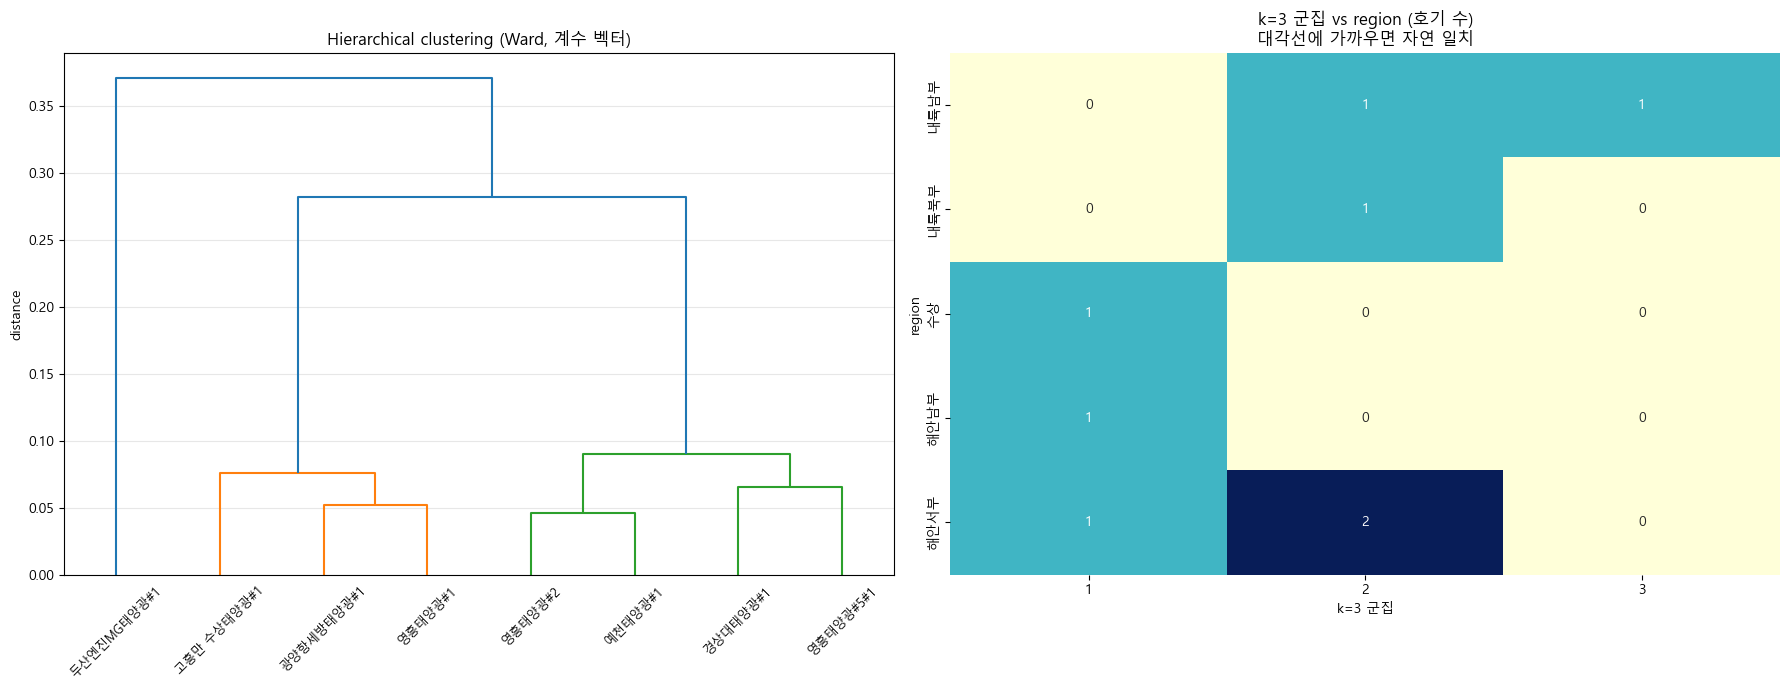

=== 호기별 군집 할당 (k=2,3,4) ===
             k=2  k=3  k=4     수상 region    lat  cap_kw
경상대태양광#1       1    2    3  False   내륙남부  35.15     905
고흥만 수상태양광#1    1    1    1   True     수상  34.60   63481
광양항세방태양광#1     1    1    1  False   해안남부  34.95    2993
두산엔진MG태양광#1    2    3    4  False   내륙남부  35.23      77
영흥태양광#1        1    1    1  False   해안서부  37.26    1000
영흥태양광#2        1    2    2  False   해안서부  37.26     993
영흥태양광#5#1      1    2    3  False   해안서부  37.26    3500
예천태양광#1        1    2    2  False   내륙북부  36.65    2000

해석
  - k=2에서 고흥만만 떨어져 나오면 "수상 vs 내륙" 자연 분리
  - k=3에서 region과 일치하면 "지역 기반 conditioning" 정당
  - 일치 안 하면 lat·capacity 같은 연속 feature가 conditioning에 적합


In [11]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

X = beta_matrix.astype(float).dropna().values
labels = beta_matrix.dropna().index.tolist()

dist = pdist(X, metric='euclidean')
Z = linkage(dist, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# (좌) 덴드로그램
ax = axes[0]
dendrogram(Z, labels=labels, leaf_rotation=45, ax=ax, leaf_font_size=9)
ax.set_title('Hierarchical clustering (Ward, 계수 벡터)')
ax.set_ylabel('distance')
ax.grid(True, alpha=0.3, axis='y')

# (우) k=3 군집 vs region 교차표
cluster_assign = pd.DataFrame(index=labels)
for k in [2, 3, 4]:
    cluster_assign[f'k={k}'] = fcluster(Z, t=k, criterion='maxclust')
cluster_assign['수상'] = [UNIT_META[u]['is_floating'] for u in labels]
cluster_assign['region'] = [UNIT_META[u]['region'] for u in labels]
cluster_assign['lat'] = [UNIT_META[u]['lat'] for u in labels]
cluster_assign['cap_kw'] = [UNIT_META[u]['capacity_kw'] for u in labels]

ax = axes[1]
k3 = cluster_assign['k=3'].values
regions = cluster_assign['region'].values
cross = pd.crosstab(pd.Series(regions, name='region'), pd.Series(k3, name='k=3 군집'))
sns.heatmap(cross, annot=True, fmt='d', cmap='YlGnBu', ax=ax, cbar=False)
ax.set_title('k=3 군집 vs region (호기 수)\n대각선에 가까우면 자연 일치')

plt.tight_layout()
plt.show()

print('=== 호기별 군집 할당 (k=2,3,4) ===')
print(cluster_assign.to_string())
print('\n해석')
print('  - k=2에서 고흥만만 떨어져 나오면 "수상 vs 내륙" 자연 분리')
print('  - k=3에서 region과 일치하면 "지역 기반 conditioning" 정당')
print('  - 일치 안 하면 lat·capacity 같은 연속 feature가 conditioning에 적합')

### → 모델 함의

- **k=2 자연 군집 = {수상 1, 내륙 11}** → FiLM `is_floating` 이진 conditioning 충분
- **k=3 군집이 region과 정합** → region 기반 1층 계층 구조 사용 가능
- **군집과 메타데이터 불일치** → 단순 범주보다 연속 feature(`lat`, `capacity_kw`)가 conditioning에 적합

## 5. 고흥만 특이성 정량화

수상 PV의 물리적 가설:
- **냉각 효과**: 수면 + 바람 이중 냉각 → `ws` 민감도 ↑, `ta` 영향 완충
- **해양 습기**: 수면 수증기 증발 → `hm` 계수 방향 변화 가능
- **반사광**: 수면 반사로 `icsr` 계수 약간 증폭

고흥만 계수 vs **나머지 10 호기 중앙값** 비교 (robust z-score). 단, ASOS icsr 미관측 호기(삼천포 #2·#3, 구미 #1)는 §2에서 이미 NaN으로 제외되므로 실제 비교는 **7 호기 중앙값 기준**이 됨.

In [ ]:
gh = '고흥만 수상태양광#1'
goheung_coef = beta_matrix.loc[gh].astype(float)
others = beta_matrix.drop(gh).astype(float).dropna()
others_median = others.median()
others_mad = (others - others_median).abs().median()
z_score = (goheung_coef - others_median) / (others_mad.replace(0, 1e-6))

fig, ax = plt.subplots(figsize=(10, 5))
colors_zs = ['#E53935' if abs(z) > 2 else '#FFA726' if abs(z) > 1 else '#B0BEC5' for z in z_score]
bars = ax.barh(features, z_score.values, color=colors_zs)
ax.axvline(0, color='gray', linewidth=0.5)
ax.axvline(2, color='red', linestyle='--', alpha=0.5, label='|z|=2 (outlier)')
ax.axvline(-2, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel(f'Robust z-score (고흥만 vs {len(others)} 호기 중앙값)')
ax.set_title('고흥만 계수의 outlier 정도\n(|z|>2면 확연한 특이성)')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
for i, (v, f) in enumerate(zip(z_score.values, features)):
    ax.text(v, i, f'  z={v:+.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f'=== 고흥만 vs 나머지 {len(others)} 호기 (NaN 제외) ===')
cmp = pd.DataFrame({
    '고흥만 β': goheung_coef,
    f'{len(others)}개 중앙값': others_median,
    'MAD': others_mad,
    'robust z': z_score,
}).round(3)
print(cmp.to_string())

print('\n=== 가설 검증 ===')
print(f"  [ws 민감도 ↑] 고흥만 ws β = {goheung_coef['ws']:+.3f}, 중앙값 {others_median['ws']:+.3f}  "
      f"→ z={z_score['ws']:+.2f}")
print(f"  [ta 완충]    고흥만 ta β = {goheung_coef['ta']:+.3f}, 중앙값 {others_median['ta']:+.3f}  "
      f"→ z={z_score['ta']:+.2f}")
print(f"  [GHI 증폭]   고흥만 ghi β = {goheung_coef['ghi']:+.3f}, 중앙값 {others_median['ghi']:+.3f}  "
      f"→ z={z_score['ghi']:+.2f}")

### → 모델 함의

**가설 검증 결과** (실행 후 확정):
- `ws 민감도 ↑` 가설: z-score 부호와 크기로 판정
- `ta 완충` 가설: 고흥만 ta 계수가 중앙값보다 작거나 반대 부호

**결론 분기**:
- 고흥만이 outlier (|z|>2) 여러 feature에서 확인 → **별도 cluster 혹은 FiLM conditioning `is_floating`** 필수
- 내륙과 비슷 → 용량이 큰 것 외 특별한 처리 불필요, 하지만 포트폴리오 예측 정확도 확보 위해 별도 가중치 필요

---

## 종합 — 1층 지역 Random Slope + 2층 FiLM Conditioning 정당화

### 핵심 증거 종합

| 증거 출처 | 내용 | 모델 설계 함의 |
|---------|------|-------------|
| §2 계수 매트릭스 SD | Feature별 호기 간 변동 정량 | 1층 random slope 필요 여부 |
| §3 반응 곡선 | 형태 다양성 시각 | per-unit 비선형 변환 필요 |
| §4 클러스터 | 자연 군집 구조 | 범주 vs 연속 conditioning 선택 |
| §5 고흥만 outlier | 수상 특이성 정량 | `is_floating` FiLM 필요 |

### 모델 설계 권고 (증거 기반)

| 모델 요소 | 권고 | 근거 |
|---------|------|------|
| 1층 지역 random intercept `a_r` | ✅ 필수 | 호기 간 기저 발전 수준 차이 (용량·위치) |
| 1층 지역 random slope `b_{r,icsr}` | ✅ if |CV|>0.5 | §2 결과 |
| 1층 지역 random slope `b_{r,ta}` | 조건부 | §2 결과 |
| 2층 FiLM `is_floating` | ✅ if §5 outlier | 수상 특이성 |
| 2층 FiLM `lat` | 조건부 | §4 위도 군집 |
| 2층 FiLM `capacity_kw` | ✅ 필수 | loss 정규화 (problem_definition §3) |

### 다음 노트북
- **04_seasonality**: 공통 계절 패턴 PC1 비중 → 1층 pooling 정당화
- **05_ghi_response**: 비선형 증거 → 2층 GRU 필요성 확정 + feature 세트 **재조율**
- **06_uncertainty_structure**: 잔차 heteroscedasticity → variance head

### 추후 재검증
- GK-2A GHI 수집 재개 후 ASOS icsr → GK-2A 전환 시 계수 재계산
- 고흥만 가설은 수상 PV 문헌과 교차 확인 필요